# How many trees does a Random Forest actually need?

`RandomForestClassifier` defaults to `n_estimators=100`. Most of the time nobody revisits
that default, and those who do usually hand the number to a hyperparameter optimiser as a
range:

```python
n_estimators = trial.suggest_int("n_estimators", 100, 2000)
```

This notebook shows, in about two minutes of compute, why that range is the problem —
and what to do instead.

**The short version:** Random Forest performance does not give you a useful interior optimum
in the number of trees. It rises and then flattens. So an optimiser asked to maximise it
inside `[100, 2000]` ends up choosing among nearly indistinguishable points on the plateau
and tends to drift toward the upper bound. Change the bound, get a different answer, for
the same data.

**PLATEAU search** removes the tree count from the search space entirely and finds where
the curve flattens, to a tolerance you choose. It comes from
[an IEEE Access 2026 paper](https://doi.org/10.1109/ACCESS.2026.3705574) and is on PyPI.


> **Quickstart.** This notebook introduces the method on one small dataset and runs in
> about two minutes. For the full benchmark behind the paper — every dataset, every
> baseline, the statistical tables and figures — see
> [`paper_repro.ipynb`](paper_repro.ipynb).
>
> It is self-contained and can also run on Kaggle or Colab after installing the package.
> The figures and metrics below are saved from a reference run; re-running the notebook
> regenerates them. Wall-clock time is intentionally omitted because it is machine-dependent.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lange-am/rf_plateau_hpo/blob/main/notebooks/quickstart.ipynb)


In [1]:
# From a clone of this repository (includes notebook dependencies):
#     pip install -e ".[dev]"
#
# On Kaggle or Colab, uncomment the next line instead:
# !pip install -q rf-plateau-hpo


In [2]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Optuna/tqdm may warn when Jupyter widgets are not installed. The progress widget is not
# used here, so keep the rendered quickstart clean.
warnings.filterwarnings("ignore", message="IProgress not found")

from rf_plateau_hpo import tune_rf_oob, tune_rf_oob_plateau

# Breast Cancer Wisconsin: binary, 569 samples, ships with scikit-learn.
X, y = load_breast_cancer(return_X_y=True)

# Out-of-bag scorer. The forest hands it (y, oob_decision_function_), so for a binary
# problem we score the positive-class column.
def auc(y_true, proba):
    return roc_auc_score(y_true, proba[:, 1])

# At very small forest sizes some samples are out-of-bag for no tree at all, and
# scikit-learn says so. That is exactly the regime we are about to look at, so the
# warning is expected rather than a problem.
warnings.filterwarnings("ignore", message="Some inputs do not have OOB scores")

print(f"{X.shape[0]} samples, {X.shape[1]} features, {np.bincount(y)} class balance")


569 samples, 30 features, [212 357] class balance


In [3]:
# --- chart styling: thin marks, recessive grid, text in ink rather than series colour ---
BLUE, ORANGE = "#2a78d6", "#eb6834"
INK, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#dcdcd8"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_MUTED, "axes.titlecolor": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED,
    "grid.color": GRID, "grid.linewidth": 0.8,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
    "figure.dpi": 120, "lines.linewidth": 2, "lines.markersize": 5,
})

---

## 1. The out-of-bag curve flattens — it does not peak

Random Forest gives us a free validation estimate: every tree is trained on a bootstrap
sample, so roughly a third of the data is out-of-bag for it. We can grow one forest
incrementally with `warm_start=True` and read the OOB score at each size, paying for each
tree exactly once.

In [4]:
sizes = [10, 20, 30, 45, 68, 100, 150, 225, 340, 510, 760, 1140, 1710, 2565]

# Plain scikit-learn: warm_start keeps the trees already grown, so raising
# n_estimators adds to the forest instead of rebuilding it. oob_score=True is what
# populates oob_decision_function_, the out-of-bag class probabilities.
forest = RandomForestClassifier(
    n_estimators=0, warm_start=True, bootstrap=True, oob_score=True,
    random_state=0, n_jobs=-1,
)

scores = []
for n in sizes:
    forest.n_estimators = n
    forest.fit(X, y)
    scores.append(auc(y, forest.oob_decision_function_))

for n, s in zip(sizes, scores):
    print(f"{n:6d} trees   OOB AUC {s:.5f}")

    10 trees   OOB AUC 0.96923
    20 trees   OOB AUC 0.98482
    30 trees   OOB AUC 0.98732
    45 trees   OOB AUC 0.98988
    68 trees   OOB AUC 0.99131
   100 trees   OOB AUC 0.99072
   150 trees   OOB AUC 0.99059
   225 trees   OOB AUC 0.99047
   340 trees   OOB AUC 0.98990
   510 trees   OOB AUC 0.98934
   760 trees   OOB AUC 0.98934
  1140 trees   OOB AUC 0.98874
  1710 trees   OOB AUC 0.98976
  2565 trees   OOB AUC 0.99041


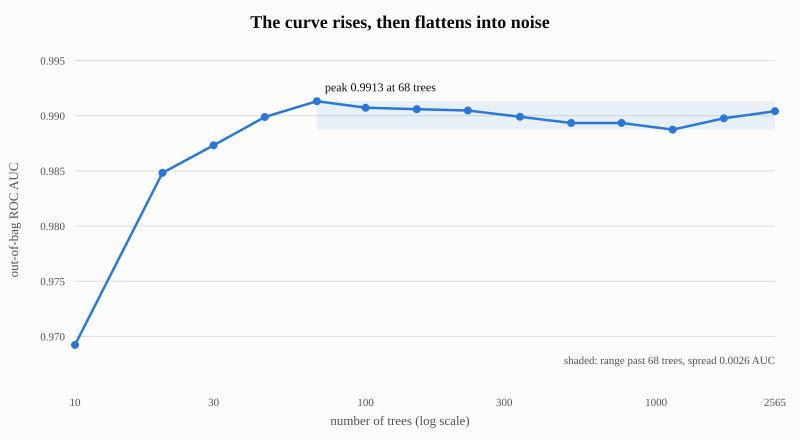

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.4))

# The noise band: everything from the 5th size onward.
tail = scores[4:]
lo, hi = min(tail), max(tail)
ax.axhspan(lo, hi, color=BLUE, alpha=0.09, zorder=1)

ax.plot(sizes, scores, "o-", color=BLUE, zorder=3)
ax.set_xscale("log")
ax.set_xlabel("number of trees (log scale)")
ax.set_ylabel("out-of-bag ROC AUC")
ax.set_title("The curve rises, then flattens into noise")
ax.grid(axis="y", zorder=0)

span = max(scores) - min(scores)
ax.set_ylim(min(scores) - span * 0.12, max(scores) + span * 0.18)

# Direct labels only where they carry the argument, never on every point.
peak = int(np.argmax(scores))
ax.annotate(f"peak {scores[peak]:.4f}\nat {sizes[peak]} trees", (sizes[peak], scores[peak]),
            textcoords="offset points", xytext=(10, 4), color=INK, fontsize=10,
            ha="left", va="bottom")
ax.annotate(f"{scores[-1]:.4f}\nat {sizes[-1]} trees", (sizes[-1], scores[-1]),
            textcoords="offset points", xytext=(-6, -34), color=INK_MUTED, fontsize=10,
            ha="right", va="bottom")
ax.annotate(f"{scores[0]:.4f}", (sizes[0], scores[0]),
            textcoords="offset points", xytext=(10, -2), color=INK_MUTED, fontsize=10,
            ha="left", va="center")

ax.text(0.99, 0.03,
        f"shaded: the whole range past {sizes[4]} trees, a spread of {hi - lo:.4f} AUC",
        transform=ax.transAxes, ha="right", va="bottom", color=INK_MUTED, fontsize=10)

plt.tight_layout(); plt.show()

Past roughly 70 trees the score stays inside a band only a few thousandths of AUC wide —
the shaded region — with no sustained direction. Those wiggles are not improvements; that is
Monte-Carlo noise from the bootstrap and the finite forest.

**This is the whole problem.** There is no useful interior maximum for an optimiser to climb
toward. Once it reaches the plateau, it is choosing among nearly indistinguishable forests.
Change the range, and the reported "best" tree count can change with it.


---

## 2. What a fixed range actually decides

Let us hand the tree count to Optuna's TPE sampler as an ordinary hyperparameter, the way
it is usually done, and run the same tuning twice — changing nothing but the upper bound.

In [6]:
def total_trees(study):
    # Trees actually grown across the whole study: the real cost of tuning.
    return sum(t.user_attrs.get("trees_built", 0) for t in study.trials)

results = {}
for t_max in (500, 2565):
    _, study = tune_rf_oob(
        X, y, "clf", auc, True,
        n_estimators_range=(100, t_max),
        n_trials=30, random_state=0, n_jobs=-1, verbose=0,
    )
    results[f"TPE [100, {t_max}]"] = {
        "n_estimators": study.best_params["n_estimators"],
        "auc": study.best_value,
        "trees": total_trees(study),
    }

for name, r in results.items():
    print(f"{name:18s}  n_estimators={r['n_estimators']:5d}  "
          f"AUC={r['auc']:.4f}  trees grown={r['trees']:6d}")


TPE [100, 500]      n_estimators=  197  AUC=0.9906  trees grown=  8398
TPE [100, 2565]     n_estimators=  688  AUC=0.9909  trees grown= 33231


Look at what changed and what did not.

The recommended forest went from a few hundred trees to several times that. The AUC moved in
the fourth decimal place. The only thing that really changed was the number we typed as the
upper bound — and the compute bill, which grew with it.

That is the problem with a fixed range: the answer is partly a property of `T_max`, not just
a property of the data.


---

## 3. PLATEAU search: no range at all

The alternative is to stop treating the tree count as something to sample, and start treating
it as something to *detect*. PLATEAU search keeps a geometric triplet of forest sizes

$$\left(\frac{B}{s_f},\; B,\; B \cdot s_f\right)$$

around a central point $B$, spaced by a **scale factor** $s_f$. At each optimisation trial it
compares out-of-bag scores across the triplet while TPE tunes depth, `max_features` and the
rest as usual. If the score barely changes to the right, the triplet has found flat ground and
slides left, towards fewer trees. If it still changes, the triplet slides right.

"Barely changes" is a **relative tolerance** $\varepsilon$ that you set: changes smaller than
$\varepsilon$ are noise you are willing to ignore.

The three symbols map onto the arguments below, and onto the notation used in the paper:

| symbol | argument | meaning |
|---|---|---|
| $T_0$ | `n_estimators_start` | where the triplet starts — a starting point, not a bound |
| $s_f$ | `scale_factor` | geometric spacing of the triplet |
| $\varepsilon$ | `delta` | relative score change treated as negligible |

There is no `[T_min, T_max]` anywhere in the call.

In [7]:
model, best_n, study_plateau, plateau_found = tune_rf_oob_plateau(
    X, y, "clf", auc, True,
    n_estimators_start=100,   # T0:  where the triplet starts, not a bound
    scale_factor=1.5,         # sf:  geometric spacing of the triplet
    delta=1e-3,               # eps: relative change treated as noise (0.1% here)
    max_trees=100_000,        # safety stop, never reached here
    n_trials=30, random_state=0, n_jobs=-1, verbose=0,
)
results["PLATEAU"] = {
    "n_estimators": best_n,
    "auc": study_plateau.best_value,
    "trees": total_trees(study_plateau),
}

print(f"plateau reached: {plateau_found}")
print(f"selected n_estimators: {best_n}")
print(f"OOB AUC: {study_plateau.best_value:.4f}")
print(f"other hyperparameters: {study_plateau.best_params}")

# What comes back is a stock scikit-learn estimator, already fitted on all of X, y.
print(f"\nreturned model: {type(model).__module__}.{type(model).__name__}")
print(f"model.n_estimators: {model.n_estimators}")
print(f"first five predictions: {model.predict(X[:5])}")


plateau reached: True
selected n_estimators: 30
OOB AUC: 0.9899
other hyperparameters: {'max_depth': 33, 'max_features': 'sqrt', 'min_samples_leaf': 11, 'min_samples_split': 22, 'criterion': 'entropy'}

returned model: sklearn.ensemble._forest.RandomForestClassifier
model.n_estimators: 30
first five predictions: [0 0 0 0 0]


### Watching the triplet walk

Every trial records its triplet, so we can watch the search decide.

In [8]:
B = [t.user_attrs["triplet"][1] for t in study_plateau.trials]
L = [t.user_attrs["triplet"][0] for t in study_plateau.trials]
R = [t.user_attrs["triplet"][2] for t in study_plateau.trials]
trials = range(len(B))

fig, ax = plt.subplots(figsize=(8, 4.4))
ax.fill_between(trials, L, R, color=BLUE, alpha=0.12, step="mid", zorder=1)
ax.step(trials, B, where="mid", color=BLUE, zorder=3)
ax.plot(trials, B, "o", color=BLUE, markersize=4, zorder=4)

# The selected size comes from the best trial, which is not necessarily the last one.
ax.axhline(best_n, color=ORANGE, linewidth=2, linestyle=(0, (4, 3)), zorder=2)
ax.annotate(f"selected: {best_n} trees", (len(B) - 1, best_n),
            textcoords="offset points", xytext=(-4, 8), color=ORANGE, fontsize=10,
            ha="right", va="bottom", fontweight="bold")

ax.set_yscale("log")
ax.set_xlabel("optimisation trial")
ax.set_ylabel("B — central point of the triplet (trees, log scale)")
ax.set_title("The triplet walks down towards the plateau")
ax.grid(axis="y", zorder=0)
ax.annotate(f"start: {B[0]} trees", (0, B[0]), textcoords="offset points",
            xytext=(8, 10), color=INK_MUTED, fontsize=10)

plt.tight_layout(); plt.show()

The shaded band is the triplet itself; the line is its centre. The walk is not monotone —
each trial samples a different set of the *other* hyperparameters, and the sufficient number
of trees genuinely depends on them. That interaction is the reason the tree count is adapted
inside the optimisation loop rather than settled before it.

---

## 4. Side by side

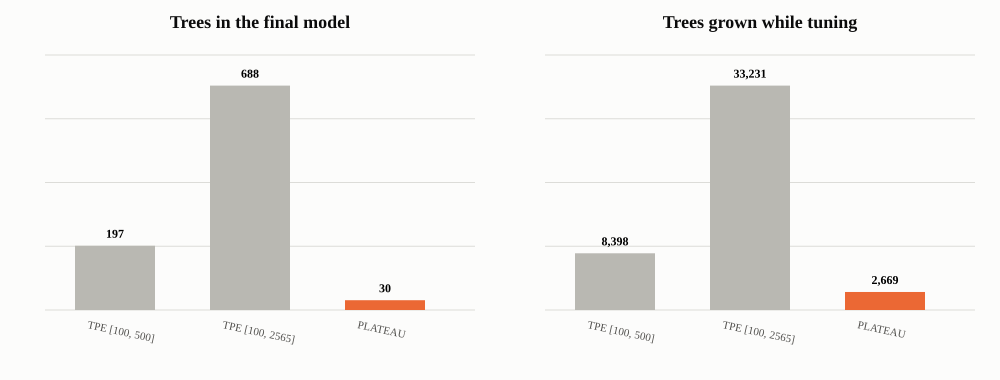

method              n_estimators   OOB AUC  trees grown
TPE [100, 500]               197    0.9906        8,398
TPE [100, 2565]              688    0.9909       33,231
PLATEAU                       30    0.9899        2,669


In [9]:
names = list(results)
vals_n = [results[k]["n_estimators"] for k in names]
vals_t = [results[k]["trees"] for k in names]
vals_a = [results[k]["auc"] for k in names]
colors = [ORANGE if k == "PLATEAU" else "#b9b8b2" for k in names]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
for ax, vals, title, fmt in (
    (axes[0], vals_n, "Trees in the final model", "{:,.0f}"),
    (axes[1], vals_t, "Trees grown while tuning", "{:,.0f}"),
):
    bars = ax.bar(names, vals, color=colors, zorder=3, width=0.62)
    ax.set_title(title)
    ax.grid(axis="y", zorder=0)
    ax.set_ylim(0, max(vals) * 1.18)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, fmt.format(v),
                ha="center", va="bottom", color=INK, fontsize=10, fontweight="bold")
    ax.tick_params(axis="x", labelrotation=12)
plt.tight_layout(); plt.show()

print(f"{'method':18s} {'n_estimators':>13s} {'OOB AUC':>9s} {'trees grown':>12s}")
for k in names:
    r = results[k]
    print(f"{k:18s} {r['n_estimators']:13,d} {r['auc']:9.4f} {r['trees']:12,d}")


In [10]:
base = results["TPE [100, 2565]"]
plat = results["PLATEAU"]
print(f"AUC difference:      {plat['auc'] - base['auc']:+.4f}")
print(f"Model size:          {base['n_estimators'] / plat['n_estimators']:.0f}x fewer trees")
print(f"Tuning cost:         {base['trees'] / plat['trees']:.0f}x fewer trees grown")


AUC difference:      -0.0010
Model size:          23x fewer trees
Tuning cost:         12x fewer trees grown


---

## What to take away

A smaller forest predicts essentially as well as one many times its size, and you did not
have to guess a range to find it. Every prediction from the smaller model is
correspondingly cheaper — which matters more in serving than in training.

The number to think about is no longer `T_max`, which you cannot justify, but $\varepsilon$
(`delta`) — the score change you are willing to call noise. That one you *can* justify, because it is
a statement about your problem: a 0.1% AUC difference either matters to you or it does not.

Three caveats worth stating plainly:

- **This is one dataset.** Breast Cancer is small and easy. The paper benchmarks the method
  across many datasets, against Hyperband and out-of-bag early stopping as well as fixed-range TPE.
- **More trees are not harmful, only expensive.** Random Forest does not overfit with ensemble
  size the way boosting can. Nothing breaks if you use 2000 trees — you just pay for them.
- **If you need stable feature importances or selection frequencies**, those converge more
  slowly than the predictive score, and this method is not tuning for them.

### Try it on your own data

```python
!pip install rf-plateau-hpo

from rf_plateau_hpo import tune_rf_oob_plateau

model, n_trees, study, found = tune_rf_oob_plateau(
    X, y, "clf", score_func, greater_is_better=True,
    n_estimators_start=100, scale_factor=1.5, delta=1e-3, n_trials=40,
)
```

For regression, pass `"reg"` with a loss such as `mean_squared_error` and
`greater_is_better=False`. If `found` comes back `False`, no trial reached a plateau within
the budget — raise `n_trials` or `max_trees`.

### Links

- **Paper** — V. A. Porvatov, A. A. Dukhovny, A. M. Lange, "How Many Trees in a Random Forest?
  A Revisited Approach With Plateau Search and Optuna Integration," *IEEE Access*, vol. 14,
  pp. 93670–93693, 2026. [doi:10.1109/ACCESS.2026.3705574](https://doi.org/10.1109/ACCESS.2026.3705574)
  (open access) · [arXiv:2606.03549](https://arxiv.org/abs/2606.03549)
- **Theory** — stationary-distribution analysis of the triplet walk:
  [arXiv:2606.30837](https://arxiv.org/abs/2606.30837)
- **Code** — [github.com/lange-am/rf_plateau_hpo](https://github.com/lange-am/rf_plateau_hpo) ·
  [PyPI](https://pypi.org/project/rf-plateau-hpo/) ·
  [project page](https://lange-am.github.io/rf_plateau_hpo/)

*If this saved you from guessing `T_max`, star the repository so other people can find it.*